# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Number of rows imported: 1000
Verification successful: 1,000 rows were imported.

Percentage of reviews:
Liked (1): 50.00%
Not Liked (0): 50.00%


/tmp/ipykernel_1867/4282131757.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=liked_percentage.index, y=liked_percentage.values, palette='viridis')


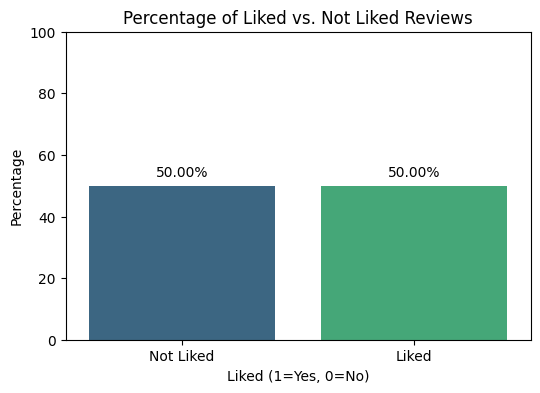

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Verify that all 1,000 rows were imported correctly
num_rows = df.shape[0]
print(f"Number of rows imported: {num_rows}")
if num_rows == 1000:
    print("Verification successful: 1,000 rows were imported.")
else:
    print(f"Verification failed: Expected 1,000 rows but got {num_rows}.")

# 4. Calculate the overall percentage of reviews that "Liked" the restaurant
liked_percentage = df['Liked'].value_counts(normalize=True) * 100
print("\nPercentage of reviews:")
print(f"Liked (1): {liked_percentage[1]:.2f}%")
print(f"Not Liked (0): {liked_percentage[0]:.2f}%")

# 5. Create a visualization to show the percentage of likes versus non-likes
plt.figure(figsize=(6, 4))
sns.barplot(x=liked_percentage.index, y=liked_percentage.values, palette='viridis')
plt.title('Percentage of Liked vs. Not Liked Reviews')
plt.xlabel('Liked (1=Yes, 0=No)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Not Liked', 'Liked'])
plt.ylim(0, 100)

# Add percentage labels on top of the bars
for index, value in enumerate(liked_percentage.values):
    plt.text(index, value + 2, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [4]:
import re

# Make a copy to avoid SettingWithCopyWarning
df_cleaned = df.copy()

# Change all reviews to lowercase
df_cleaned['Review'] = df_cleaned['Review'].str.lower()

# Remove URLs (a common pattern for URLs is http/https followed by non-whitespace characters)
df_cleaned['Review'] = df_cleaned['Review'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

# Remove anything that isn't a regular character (A to Z) or number (0-9) or basic spaces
# This keeps letters, numbers, and spaces, removing other symbols.
df_cleaned['Review'] = df_cleaned['Review'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

# Remove punctuation marks explicitly (though the above regex should handle most)
# This step is more targeted for any remaining punctuation that might not be caught by the alphanumeric filter
# Or if the user meant to keep some special characters but remove only punctuation.
# Given the instruction 'remove anything that isn't a regular character (A to Z) or number (1-9)'
# and 'Remove punctuation marks (ex. !.,-:;)', the alphanumeric filter is quite aggressive.
# Let's ensure only letters and numbers remain based on the 'not a regular character' part.
# Re-applying a more targeted punctuation removal after the broad filter might be redundant but safe.
# A simpler approach that combines the two requirements:
# Keep only letters, numbers, and spaces.

df_cleaned['Review'] = df_cleaned['Review'].apply(lambda x: re.sub(r'[^a-z0-9 ]', '', x))

# Optionally, remove extra spaces that might result from cleaning
df_cleaned['Review'] = df_cleaned['Review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("First 5 cleaned reviews:")
print(df_cleaned['Review'].head())


First 5 cleaned reviews:
0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
Name: Review, dtype: object


### ✍️ Your Response: 🔧
1. If we included the review junk, we would create unnecceacry noise wich would make any model we train less effective. Doing this also creates the potential for missintrprated data, slows model training, and create unnecacry dimesionality.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [5]:
# Install vaderSentiment if not already installed
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment label
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    # Classify based on compound score
    if scores['compound'] >= 0.05:
        return 'Positive'
    elif scores['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to the cleaned reviews
df_cleaned['Sentiment'] = df_cleaned['Review'].apply(get_sentiment)

# Calculate the percentage of each sentiment type
sentiment_counts = df_cleaned['Sentiment'].value_counts(normalize=True) * 100

print("\nPercentage of reviews by sentiment:")
print(sentiment_counts)

# Verify that percentages add up to 100%
print(f"Total percentage: {sentiment_counts.sum():.2f}%")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.1 MB/s eta 0:00:00

Percentage of reviews by sentiment:
Sentiment
Positive    50.6
Negative    25.5
Neutral     23.9
Name: proportion, dtype: float64
Total percentage: 100.00%


### ✍️ Your Response: 🔧
1. The sentiment Liked when compared to the percentage of reviews shows that 50.6% of the people who liked had positive reviews, 25.5% had negitive reviews, and 23.9% had neutral reviews. From the data, we can see that 50% of people who liked had a positive review. Thus, we can say that people who like are likely to have a postive experince.

2. From a restaurant owners presepctive, or any bussnies really, The negitive sediment review would be the more important to analze. I want to know what is making customers have a bad experice— how can I prevent this. Anwsering this question will help me run a better and more effiect bussnies.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data unconditionally to ensure all components are present
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True) # Punkt tokenizer often includes 'punkt_tab'
nltk.download('punkt_tab', quiet=True) # Explicitly download punkt_tab as suggested by error

# Initialize lemmatizer and load stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to preprocess text: tokenize, remove stopwords, lemmatize
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and perform lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha() # Ensure it's an alphabet word
    ]
    return " ".join(processed_tokens)

# Apply preprocessing to the cleaned reviews
df_cleaned['Processed_Review'] = df_cleaned['Review'].apply(preprocess_text)

# Display the first 10 processed reviews
print("First 10 processed reviews:")
for i, review in enumerate(df_cleaned['Processed_Review'].head(10)):
    print(f"{i+1}. {review}")

First 10 processed reviews:
1. wow loved place
2. crust good
3. tasty texture nasty
4. stopped late may bank holiday rick steve recommendation loved
5. selection menu great price
6. getting angry want damn pho
7. honeslty didnt taste fresh
8. potato like rubber could tell made ahead time kept warmer
9. fry great
10. great touch


### ✍️ Your Response: 🔧
1. Corpora is a large set of structured texts. It is usefull for lingustic and analitical reshearch when it comes to trainging predictive models.

2. The tokens in the first review would be: "wow", "loved", "this", "place".

3. Lemmatization is the process of reducing useless tokenized words. This reduces noise and makes the dataset easier to model. For exsample, "this" is not an important token and would be removed with lemmatization.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [15]:
!pip install gensim
from gensim import corpora

# Create a list of tokenized reviews from the 'Processed_Review' column
# This assumes Processed_Review is a string of space-separated tokens
tokenized_reviews = [review.split() for review in df_cleaned['Processed_Review']]

# 1. Create a dictionary
dictionary = corpora.Dictionary(tokenized_reviews)

# 2. Create a corpus (Bag-of-Words representation)
corpus = [dictionary.doc2bow(review) for review in tokenized_reviews]

# 3. Display a summary of the dictionary and corpus
print("Dictionary Summary:")
print(f"Number of unique words (tokens): {len(dictionary)}")
# print(f"First 10 dictionary items: {list(dictionary.items())[:10]}") # Can be too verbose

print("\nCorpus Summary (first 5 documents):")
for i, doc in enumerate(corpus[:5]):
    print(f"Document {i+1}: {doc}")

print(f"\nTotal number of documents in corpus: {len(corpus)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.3 MB/s eta 0:00:00
Dictionary Summary:
Number of unique words (tokens): 1809

Corpus Summary (first 5 documents):
Document 1: [(0, 1), (1, 1), (2, 1)]
Document 2: [(3, 1), (4, 1)]
Document 3: [(5, 1), (6, 1), (7, 1)]
Document 4: [(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
Document 5: [(16, 1), (17, 1), (18, 1), (19, 1)]

Total number of documents in corpus: 1000


### ✍️ Your Response: 🔧
1. Corpus is a collection of documents that are represented in a numerical form. In a sense, these numerical documents are words that can be used for training and model input.
2. A corpus is diffrent than a dictionary because of their purposes. A dictionary is used to token every word within a document. This can help map and define a document. On the other hand, a corpus is a representation of the document as numerical vectors. This allows us to see how the words in a document relate to one another.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [16]:
from gensim.models import LdaModel

# Select the number of topics
num_topics = 5

# Create the LDA model
# Set passes to a reasonable number, e.g., 50, for better convergence
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=50, random_state=100)

print("LDA Model created successfully with 5 topics.")

LDA Model created successfully with 5 topics.


### ✍️ Your Response: 🔧
1. It would be best to use more than 5 topics if the data set was larger and more diverse, if the person anaylizing it needed a deeper and more insightfull look into the data, or if there was a specific business question at hand. If we are not trying to uncover a super deep question, more than 5 topics is not required.

2. One would be able to tell if they had to many topics based on the model they created. If there is overlap, redudancy, uninterprateable topics, or low coherece, it is likely that there are too many topics present.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"



--- Topics and Top Words ---
Topic #0: 0.016*"place" + 0.014*"great" + 0.013*"time" + 0.012*"amazing" + 0.010*"food" + 0.010*"would" + 0.010*"service" + 0.007*"good" + 0.007*"minute" + 0.007*"even"
Topic #1: 0.014*"pretty" + 0.012*"really" + 0.012*"one" + 0.010*"good" + 0.010*"experience" + 0.009*"waited" + 0.009*"quality" + 0.007*"food" + 0.007*"wasnt" + 0.006*"time"
Topic #2: 0.024*"food" + 0.014*"service" + 0.012*"delicious" + 0.011*"great" + 0.009*"burger" + 0.009*"also" + 0.009*"salad" + 0.008*"good" + 0.008*"time" + 0.007*"selection"
Topic #3: 0.029*"good" + 0.026*"food" + 0.023*"back" + 0.021*"place" + 0.020*"go" + 0.016*"like" + 0.012*"service" + 0.010*"dont" + 0.010*"ever" + 0.009*"never"
Topic #4: 0.026*"place" + 0.015*"great" + 0.014*"service" + 0.010*"price" + 0.009*"fantastic" + 0.009*"menu" + 0.009*"food" + 0.008*"get" + 0.007*"everything" + 0.007*"steak"

--- Topic Frequencies (Number of Documents per Topic) ---
Dominant_Topic
4    173
3    306
2    218
0    167
1    13

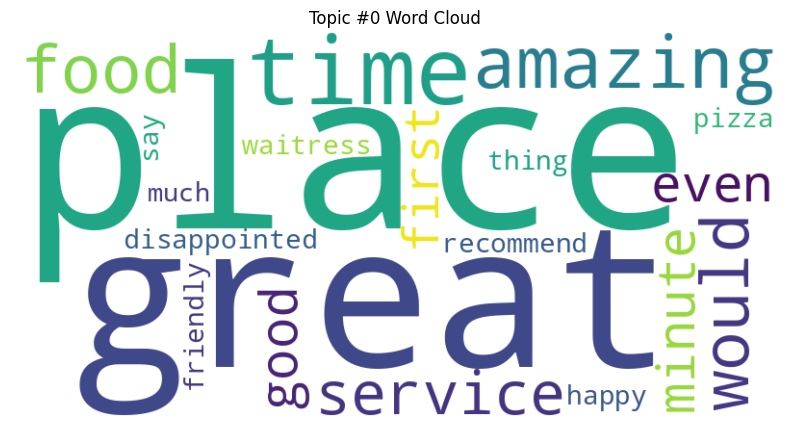

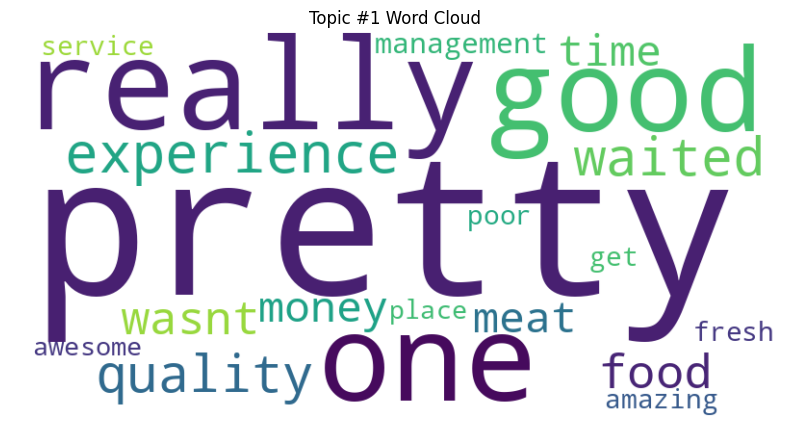

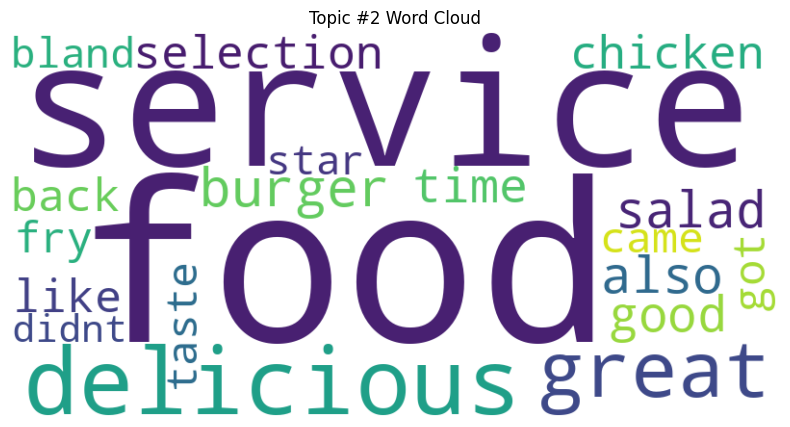

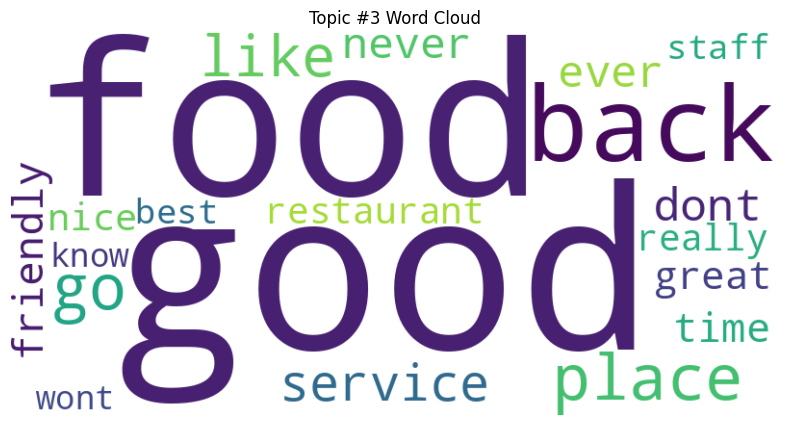

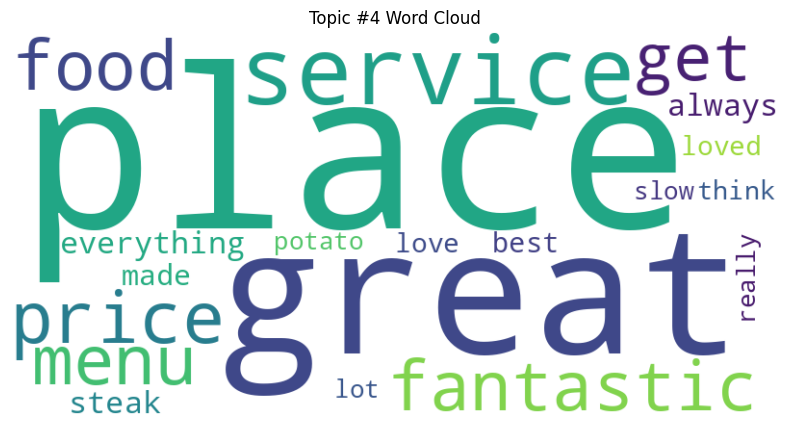


--- Sentiment Summary by Topic ---
Sentiment        Negative    Neutral   Positive
Dominant_Topic                                 
0               28.742515  17.365269  53.892216
1               33.088235  22.058824  44.852941
2               25.688073  25.688073  48.623853
3               24.509804  25.163399  50.326797
4               17.919075  27.167630  54.913295


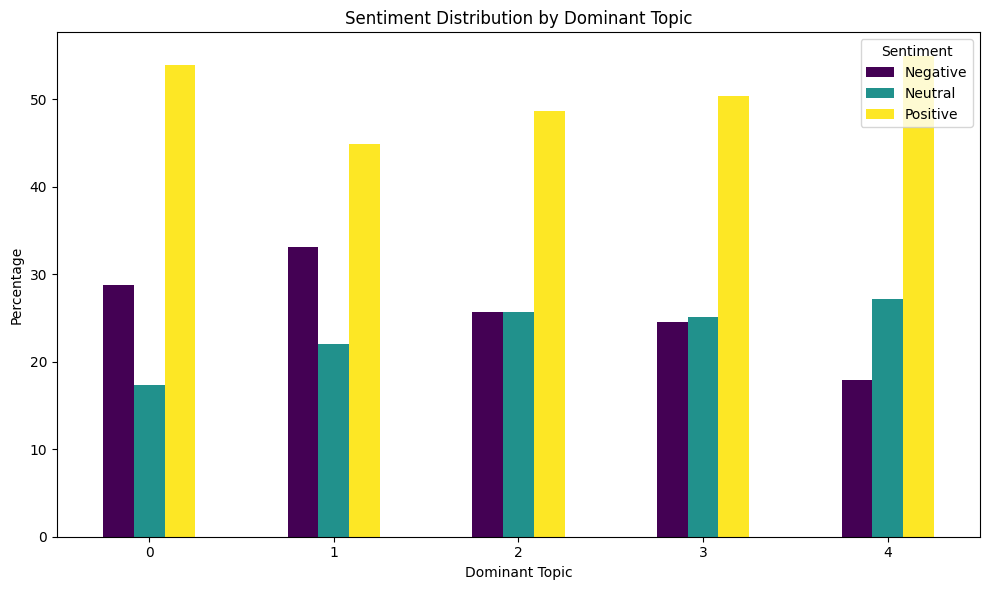

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# 1. Print the topics and top 10 words in the topic
print("\n--- Topics and Top Words ---")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic #{idx}: {topic}")

# 2. Calculate the frequency of each topic
# Get dominant topic for each document
def get_dominant_topic(ldamodel, corpus, texts):
    # Init output
    topic_info = []
    for i, corp in enumerate(corpus):
        # Get topic distributions for this document
        topic_distribution = ldamodel.get_document_topics(corp)
        # Get the dominant topic (topic with highest probability)
        if topic_distribution:
            dominant_topic = max(topic_distribution, key=lambda item: item[1])
            topic_info.append(dominant_topic[0]) # Append just the topic ID
        else:
            topic_info.append(-1) # No topic found for an empty document
    return topic_info

# Add dominant topic to df_cleaned
df_cleaned['Dominant_Topic'] = get_dominant_topic(lda_model, corpus, df_cleaned['Processed_Review'])

# Calculate topic frequencies
topic_counts = df_cleaned['Dominant_Topic'].value_counts(sort=False)
print("\n--- Topic Frequencies (Number of Documents per Topic) ---")
print(topic_counts)

# 3. Attempt at least one visual display of the topics (Word Clouds)
print("\n--- Word Clouds for Each Topic ---")
for i, topic in lda_model.show_topics(formatted=False, num_words=20):
    # Convert topic words and weights to a dictionary for WordCloud
    topic_word_dict = {word: weight for word, weight in topic}

    # Generate word cloud
    wordcloud = WordCloud(background_color="white",
                          width=800, height=400,
                          random_state=42,
                          max_words=100).generate_from_frequencies(topic_word_dict)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic #{i} Word Cloud')
    plt.axis("off")
    plt.show()

# 4. Summarize the sentiment by topic
print("\n--- Sentiment Summary by Topic ---")
sentiment_by_topic = df_cleaned.groupby('Dominant_Topic')['Sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100
print(sentiment_by_topic)

# Optional: Visualize sentiment by topic
sentiment_by_topic.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Sentiment Distribution by Dominant Topic')
plt.ylabel('Percentage')
plt.xlabel('Dominant Topic')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
List your topics and names here:

Topic #0 - Overall Positive Experience
Keywords: place, great, amazing, food, service, good

Topic #1 - Mixed Quality/Wait
Keywords: good, experience, waited, quality, wasnt, time

Topic #2 - Delicious Food & Service
Keywords: food, service, delicious, great, burger, salad

Topic #3 - Return Intention
Keywords: good, food, back, place, go, like, dont, never

opic #4 - Excellent Value/Service
Keywords: place, great, service, price, fantastic, menu, food


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model I created helped anwser the business question related to: what customer themes related to a postive review. We wanted to find out what makes a customer leave a postives, negitive, or neutral review.

2.  From looking at the data the model produced, we can see that the signals that lead to negitive customer reviews delt with service and quality consistincy. From this knowlage, I would recomend that the business owner improve the consistisy of his quality, and reduce the customer wait times. This should lead to better customer reviews and thus satisfaction.

3.  The pros of using and LLM compared to python models mostly comes down to usablility. Both are more than capiable of completing this kind of task; however, it is easier to model things with and LLM, and ask diffrent questions. You can get a deeper insight and learn what the data acualy meas. Using pythin models is far more time consuming and many hide posiable insights that an LLM can catch.

4.  If I was to use an LLM to model this kind of data, I would structure a prompt like this: " You are a senior data analyist at my company. I am tasking you with discovering _________. Here is a dataset that I have collected that conations _____. Please use this data to find connections, relationships, and usefull insights that might help us anwser ______. If you find anything that is out of the ordinarly please let me know. If you clean the dataset at all please let me know how, and what you changed.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [18]:
!jupyter nbconvert --to html "assignment_13_text_analytics_TettelbachIanb.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics_TettelbachIanb.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1256671 bytes to assignment_13_text_analytics_TettelbachIanb.html
